In [2]:
# Imports:
import numpy as np
import os
import pandas as pd
from lerobot.datasets.lerobot_dataset import LeRobotDataset
import matplotlib.pyplot as plt
from pathlib import Path
import json

## 1. Read everything using standard packages:

In [3]:
# folder_path = os.getcwd()
# file_path = '/so101_policy_robustness/meta'
ROOT = Path.home() / "datasets/act-diffusion-vla-so101/so101_policy_robustness"
SUP_PATH = Path.home() / ".cache/huggingface/lerobot/TamaraSumarac/so101_policy_robustness_v2_supplement"
full_path = ROOT / "meta"
print(os.listdir(full_path))
df = pd.read_json(full_path / 'info.json')
# print(df)
df2 = pd.read_parquet(full_path / 'tasks.parquet')
# print(df2)
df3 = pd.read_parquet(full_path / 'episodes/chunk-000/file-000.parquet')
# print(df3)

['.DS_Store', 'episodes', 'info.json', 'tasks.parquet', 'stats.json']


## 2. Read everything with LeRobot package:

## 2.1. Load data using LeRobot package:

In [4]:
ds =  LeRobotDataset("TamaraSumarac/so101_policy_robustness", root=str(ROOT))
ds_sup = LeRobotDataset("TamaraSumarac/so101_policy_robustness_v2_supplement", root=str(SUP_PATH))
ds

objc[3454]: Class AVFFrameReceiver is implemented in both /Users/tamara/miniforge3/envs/lerobot/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x11499c3a8) and /Users/tamara/miniforge3/envs/lerobot/lib/libavdevice.62.3.102.dylib (0x12fd287a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[3454]: Class AVFAudioReceiver is implemented in both /Users/tamara/miniforge3/envs/lerobot/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x11499c3f8) and /Users/tamara/miniforge3/envs/lerobot/lib/libavdevice.62.3.102.dylib (0x12fd287f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


LeRobotDataset({
    Repository ID: 'TamaraSumarac/so101_policy_robustness',
    Number of selected episodes: '50',
    Number of selected samples: '26689',
    Features: '['action', 'observation.state', 'observation.images.front', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})

## 2.2 Schema features:

In [5]:
ds.meta.features

{'action': {'dtype': 'float32',
  'names': ['shoulder_pan.pos',
   'shoulder_lift.pos',
   'elbow_flex.pos',
   'wrist_flex.pos',
   'wrist_roll.pos',
   'gripper.pos'],
  'shape': (6,)},
 'observation.state': {'dtype': 'float32',
  'names': ['shoulder_pan.pos',
   'shoulder_lift.pos',
   'elbow_flex.pos',
   'wrist_flex.pos',
   'wrist_roll.pos',
   'gripper.pos'],
  'shape': (6,)},
 'observation.images.front': {'dtype': 'video',
  'shape': (480, 640, 3),
  'names': ['height', 'width', 'channels'],
  'info': {'is_depth_map': False,
   'video.height': 480,
   'video.width': 640,
   'video.codec': 'av1',
   'video.pix_fmt': 'yuv420p',
   'video.fps': 30,
   'video.channels': 3,
   'has_audio': False,
   'video.g': 2,
   'video.crf': 30,
   'video.preset': 12,
   'video.fast_decode': 0,
   'video.video_backend': 'pyav',
   'video.extra_options': {}}},
 'timestamp': {'dtype': 'float32', 'shape': (1,), 'names': None},
 'frame_index': {'dtype': 'int64', 'shape': (1,), 'names': None},
 'epis

## 2.3. ds is loaded per frame

In [6]:
len(ds)

26689

## 2.4. Print one frame:

In [7]:
frame = ds[10000]
for k,v in frame.items():
    try:
        print(f"{k:35s} {type(v).__name__:10s} {tuple(v.shape)} {v.dtype}")
    except AttributeError:
        print(f"{k:35s} {v}")

observation.images.front            Tensor     (3, 480, 640) torch.float32
action                              Tensor     (6,) torch.float32
observation.state                   Tensor     (6,) torch.float32
timestamp                           Tensor     () torch.float32
frame_index                         Tensor     () torch.int64
episode_index                       Tensor     () torch.int64
index                               Tensor     () torch.int64
task_index                          Tensor     () torch.int64
task                                Pick up the pink block and place it in the plate


In [8]:
list(frame.items())[0]

('observation.images.front',
 tensor([[[0.3137, 0.3137, 0.3137,  ..., 0.4471, 0.4471, 0.4471],
          [0.3137, 0.3137, 0.3137,  ..., 0.4431, 0.4431, 0.4431],
          [0.3137, 0.3137, 0.3137,  ..., 0.4392, 0.4392, 0.4392],
          ...,
          [0.0549, 0.0549, 0.0549,  ..., 0.5843, 0.5765, 0.5765],
          [0.0549, 0.0549, 0.0549,  ..., 0.5843, 0.5765, 0.5725],
          [0.0549, 0.0549, 0.0549,  ..., 0.5882, 0.5765, 0.5725]],
 
         [[0.4235, 0.4235, 0.4235,  ..., 0.5647, 0.5647, 0.5647],
          [0.4235, 0.4235, 0.4235,  ..., 0.5569, 0.5569, 0.5569],
          [0.4235, 0.4235, 0.4235,  ..., 0.5529, 0.5529, 0.5529],
          ...,
          [0.0510, 0.0510, 0.0510,  ..., 0.5608, 0.5647, 0.5647],
          [0.0510, 0.0510, 0.0510,  ..., 0.5608, 0.5647, 0.5608],
          [0.0510, 0.0510, 0.0510,  ..., 0.5686, 0.5647, 0.5608]],
 
         [[0.5020, 0.5020, 0.5020,  ..., 0.5686, 0.5686, 0.5686],
          [0.5020, 0.5020, 0.5020,  ..., 0.5647, 0.5647, 0.5647],
          [

In [9]:
print(frame['observation.state'])
print(frame['action'])

tensor([  12.3956, -101.2747,   91.5165,   61.1868,    0.3956,    1.1111])
tensor([  12.2637, -101.2308,   89.4945,   58.9451,    0.4835,    1.0888])


In [10]:
print(frame["episode_index"])    # which episode this frame belongs to
print(frame["frame_index"])      # position within that episode (resets to 0 each episode)
print(frame["index"])            # global position (== 1000 here)

tensor(18)
tensor(92)
tensor(10000)


## 2.5 Episode lengths + fps vs protocol:

In [11]:
print( "fps:", ds.fps)
lengths = [ds.meta.episodes[i]["length"] for i in range(ds.num_episodes)]
print("episdoes:", ds.num_episodes)
print("min/median/max length:", np.min(lengths), int(np.median(lengths)), np.max(lengths))
print("seconds:", np.min(lengths)/ds.fps, "to", np.max(lengths)/ds.fps)

fps: 30
episdoes: 50
min/median/max length: 455 526 655
seconds: 15.166666666666666 to 21.833333333333332


## 3. How much time should i cut for best dataset:

In [12]:
import torch

def motion_onset(ds, ep, thresh=2.0):   # thresh in joint units; tune by eyeballing one episode
    e = ds.meta.episodes[ep]
    start, end = e["dataset_from_index"], e["dataset_to_index"]
    a0 = ds[start]["action"]
    for i in range(start, end):
        if torch.max(torch.abs(ds[i]["action"] - a0)) > thresh:
            return i - start   # frame_index of first real motion
    return 0

def motion_idle(ds, ep, thresh=2.0):   # thresh in joint units; tune by eyeballing one episode
    e = ds.meta.episodes[ep]
    start, end = e["dataset_from_index"], e["dataset_to_index"]
    a_last = ds[end-1]["action"]
    for i in range(end-2, start-1, -1):
        if torch.max(torch.abs(ds[i]["action"] - a_last)) > thresh:
            return end - 1 - i   # number of frames from the end
    return 0

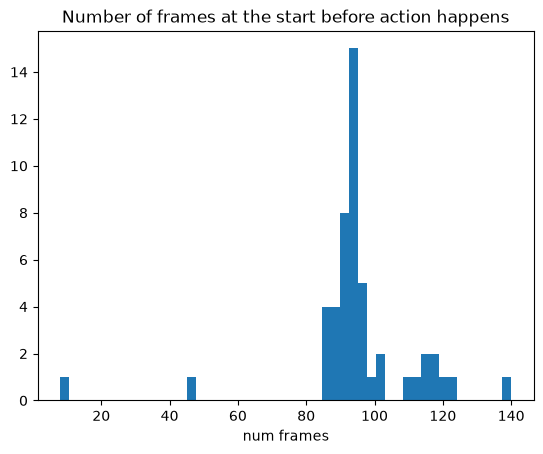

In [13]:
num_episodes = ds.num_episodes
head_result = np.zeros(num_episodes)
for i in range(num_episodes):
    head_result[i] = motion_onset(ds,i)

plt.hist(head_result, bins = num_episodes)
plt.xlabel('num frames')
plt.title('Number of frames at the start before action happens')
plt.show()

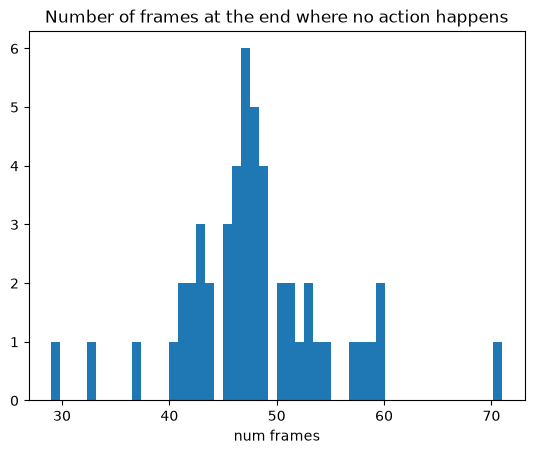

In [14]:
num_episodes = ds.num_episodes
tail_result = np.zeros(num_episodes)
for i in range(num_episodes):
    tail_result[i] = motion_idle(ds,i)

plt.hist(tail_result, bins = num_episodes)
plt.xlabel('num frames')
plt.title('Number of frames at the end where no action happens')
plt.show()

In [15]:
import json

trim = {
    int(ep): {"head": int(head_result[ep]), "tail": int(tail_result[ep])}
    for ep in range(ds.num_episodes)
}
with open("trim_frames.json", "w") as f:
    json.dump(trim, f, indent=2)

In [16]:
e = ds.meta.episodes[12]
start, end = e["dataset_from_index"], e["dataset_to_index"]
a_last = ds[end-1]["action"]
print(a_last)

tensor([  14.7253, -101.1429,   93.6264,   58.9451,   -1.8022,    1.0888])


### Let's fix episode 12 and 22 (starting the counting from 0) as they register fake movement at frame 10 and 46, but actual movement happens later (confirmed in video and follower/leader states):

In [17]:
with open("trim_frames.json") as f:
    trims = json.load(f)

trims["13"]["head"] = 80   # <- your read-off value
trims["23"]["head"] = 80   # <- your read-off value

with open("trim_frames.json", "w") as f:
    json.dump(trims, f, indent=2)

# 4. Re-recorded data for better representation and let's do trimming for those:

supplement episodes: 16 | fps: 30
length (s): min/median/max 16.2 19.883333333333333 22.633333333333333


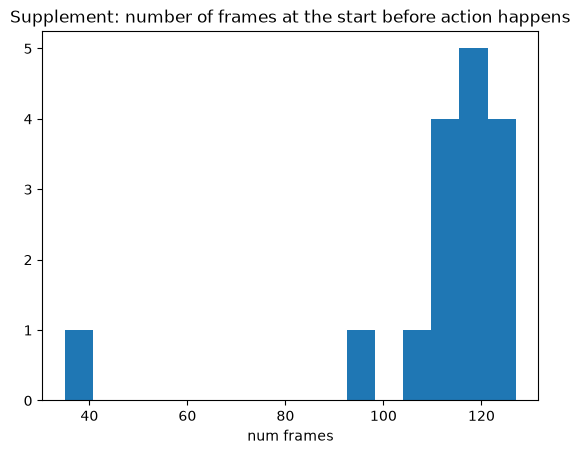

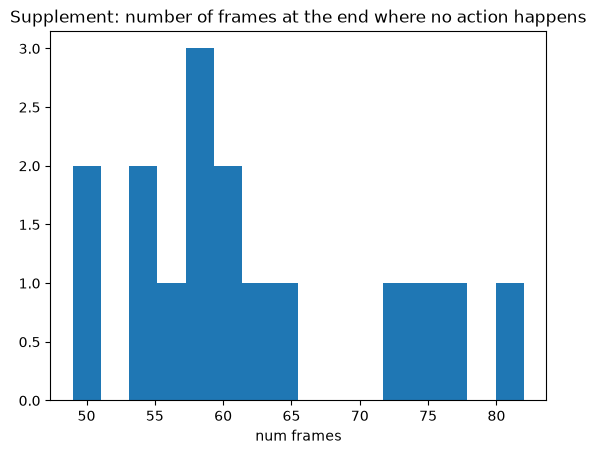

head (frames): [ 35 115 122 115 124  94 117 117 107 119 112 118 111 127 118 123]
tail (frames): [82 77 62 59 55 65 50 59 74 57 59 55 60 60 49 72]


In [18]:
## 4. Trim the v2 supplement (16 edge-midpoint episodes)
print("supplement episodes:", ds_sup.num_episodes, "| fps:", ds_sup.fps)

lengths_sup = [ds_sup.meta.episodes[i]["length"] for i in range(ds_sup.num_episodes)]
print("length (s): min/median/max",
      np.min(lengths_sup)/ds_sup.fps, np.median(lengths_sup)/ds_sup.fps, np.max(lengths_sup)/ds_sup.fps)

# same detector, same threshold as v1 — do not retune per dataset
num_episodes_sup = ds_sup.num_episodes
head_sup = np.zeros(num_episodes_sup)
for i in range(num_episodes_sup):
    head_sup[i] = motion_onset(ds_sup, i)

plt.hist(head_sup, bins=num_episodes_sup)
plt.xlabel('num frames')
plt.title('Supplement: number of frames at the start before action happens')
plt.show()

tail_sup = np.zeros(num_episodes_sup)
for i in range(num_episodes_sup):
    tail_sup[i] = motion_idle(ds_sup, i)

plt.hist(tail_sup, bins=num_episodes_sup)
plt.xlabel('num frames')
plt.title('Supplement: number of frames at the end where no action happens')
plt.show()

print("head (frames):", head_sup.astype(int))
print("tail (frames):", tail_sup.astype(int))

In [19]:
### Fix supplement episode 0: detector fires at frame 35 on a twitch; real motion starts ~4 s (confirmed on video)
head_sup[0] = 118   # median of the cluster; conservative — -15 margin at load keeps ~0.5 s pre-motion

trim_sup = {int(ep): {"head": int(head_sup[ep]), "tail": int(tail_sup[ep])}
            for ep in range(ds_sup.num_episodes)}
with open("trim_frames_v2_supplement.json", "w") as f:
    json.dump(trim_sup, f, indent=2)

# merged v2 trims: v1 keys 0..49 unchanged, supplement becomes 50..65
with open("trim_frames.json") as f:
    trim_v1 = json.load(f)
OFFSET = ds.num_episodes   # 50
trim_v2 = {**trim_v1, **{str(ep + OFFSET): v for ep, v in trim_sup.items()}}
with open("trim_frames_v2.json", "w") as f:
    json.dump(trim_v2, f, indent=2)
print(f"trim_frames_v2.json: {len(trim_v2)} episodes")

trim_frames_v2.json: 66 episodes


# 5. Build one dataset that combines both recordings

In [20]:
## 5. Build v2 = v1 + supplement as a NEW dataset (originals untouched)
import inspect
from pathlib import Path
from lerobot.datasets.lerobot_dataset import LeRobotDataset
from lerobot.datasets import dataset_tools

# print the real signature first — arg names vary slightly between 0.6.x builds
print(inspect.signature(dataset_tools.merge_datasets))

V2_PATH = Path.home() / "datasets/act-diffusion-vla-so101/so101_policy_robustness_v2"
assert not V2_PATH.exists(), f"{V2_PATH} already exists — refusing to overwrite"

ds_v1  = LeRobotDataset("TamaraSumarac/so101_policy_robustness",               root=str(ROOT))
ds_sup = LeRobotDataset("TamaraSumarac/so101_policy_robustness_v2_supplement", root=str(SUP_PATH))

ds_v2 = dataset_tools.merge_datasets(
    [ds_v1, ds_sup],                       # order matters: v1 episodes 0..49, supplement 50..65
    output_repo_id="TamaraSumarac/so101_policy_robustness_v2",
    output_dir=str(V2_PATH),
)

# ---- verification ----------------------------------------------------------
print("episodes:", ds_v2.num_episodes, "(expect 66)")
print("frames:  ", ds_v2.num_frames,   "(expect", ds_v1.num_frames + ds_sup.num_frames, ")")
assert ds_v2.num_episodes == 66
assert ds_v2.num_frames == ds_v1.num_frames + ds_sup.num_frames

# episode 50 of v2 must be episode 0 of the supplement
import torch
e50 = ds_v2.meta.episodes[50]["dataset_from_index"]
e0  = ds_sup.meta.episodes[0]["dataset_from_index"]
assert torch.allclose(ds_v2[e50]["observation.state"], ds_sup[e0]["observation.state"]), \
    "episode 50 of v2 is NOT supplement episode 0 — ordering wrong"
print("episode 50 == supplement episode 0: OK")

# expected sampler coverage after trims, for the cloud runbook watchlist
import json
with open("trim_frames_v2.json") as f:
    trim_v2 = {int(k): v for k, v in json.load(f).items()}
n = sum(ds_v2.meta.episodes[i]["length"] - max(0, t["head"]-15) - max(0, t["tail"]-15)
        for i, t in trim_v2.items())
print(f"[trim] sampler should cover {n} frames  <- put this in the runbook watchlist")

(datasets: list[lerobot.datasets.lerobot_dataset.LeRobotDataset], output_repo_id: str, output_dir: str | pathlib.Path | None = None, concatenate_videos: bool = True, concatenate_data: bool = True) -> lerobot.datasets.lerobot_dataset.LeRobotDataset


AssertionError: /Users/tamara/datasets/act-diffusion-vla-so101/so101_policy_robustness_v2 already exists — refusing to overwrite

# 6. Resolving jerkyness of async rollout 

demo  median 0.53  p95 3.75  max 5.63  frames 527
rtc   median 2.73  p95 7.46  max 9.85  frames 423


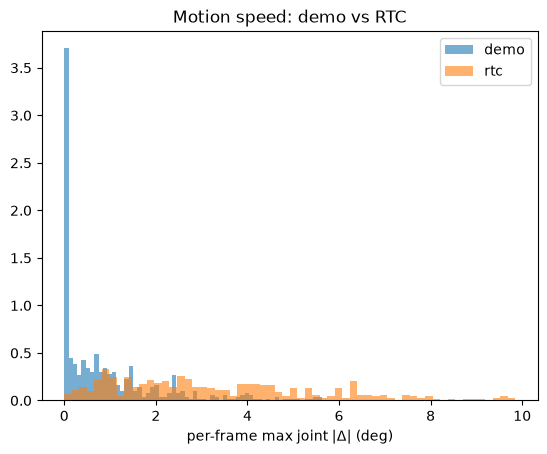

In [23]:
# RTC_PATH = Path.home() / ".cache/huggingface/lerobot/TamaraSumarac/rollout_rtc_probe_smolvla_20260831_123022"
RTC_PATH = Path.home() / ".cache/huggingface/lerobot/TamaraSumarac/rollout_rtc_probe_smolvla_eh30_20260831_124947" # event horizon = 30
ds_rtc = LeRobotDataset("TamaraSumarac/rollout_rtc_probe_smolvla", root=str(RTC_PATH))

def ep_deltas(ds_, ep):
    e = ds_.meta.episodes[ep]
    s = np.stack([ds_[i]["observation.state"].numpy()
                  for i in range(e["dataset_from_index"], e["dataset_to_index"])])
    return np.abs(np.diff(s, axis=0)).max(axis=1)

d_demo = ep_deltas(ds, 0)         # a v1 demo episode
d_rtc  = ep_deltas(ds_rtc, 1)     # the probe (episode 1, not the warm-up)

for name, d in [("demo", d_demo), ("rtc", d_rtc)]:
    print(f"{name:5s} median {np.median(d):.2f}  p95 {np.percentile(d,95):.2f}  max {d.max():.2f}  frames {len(d)}")

plt.hist(d_demo, bins=60, alpha=0.6, label="demo", density=True)
plt.hist(d_rtc,  bins=60, alpha=0.6, label="rtc",  density=True)
plt.xlabel("per-frame max joint |Δ| (deg)"); plt.legend(); plt.title("Motion speed: demo vs RTC")
plt.show()